# Bank Customer Churn Prediction: End-to-End ML Pipeline

## Problem Statement

Customer churn is a critical challenge in the banking industry, representing the loss of clients who discontinue their relationship with the bank. This project addresses the challenge of predicting customer churn for ABC Multistate Bank using machine learning techniques.

### Business Context
- It costs 5-25 times more to acquire new customers than to retain existing ones
- Early identification of potential churners allows proactive retention measures
- Understanding churn factors helps in improving customer service and products

### Technical Approach
We are building an end-to-end machine learning pipeline using PySpark and DVC that:
1. Processes customer data including demographics, account information, and transaction history
2. Engineers relevant features that might indicate churn probability
3. Trains and evaluates multiple ML models to predict customer churn
4. Tracks experiments and maintains reproducibility using DVC


## Data Dictionary

This dataset contains customer information from ABC Multistate Bank, used for predicting customer churn. Below is a detailed description of each feature:

| Feature | Description | Type |
|---------|-------------|------|
| `customer_id` | Unique identifier for each customer | Integer |
| `credit_score` | Customer's credit score (350-850) | Integer |
| `country` | Customer's country of residence (France, Spain, Germany) | Categorical |
| `gender` | Customer's gender (Male/Female) | Categorical |
| `age` | Customer's age in years (18-92) | Integer |
| `tenure` | Number of years the customer has been with the bank (0-10) | Integer |
| `balance` | Current account balance in currency units (0-250,898) | Float |
| `products_number` | Number of bank products the customer uses (1-4) | Integer |
| `credit_card` | Whether the customer has a credit card (1=Yes, 0=No) | Binary |
| `active_member` | Whether the customer is an active member (1=Yes, 0=No) | Binary |
| `estimated_salary` | Estimated annual salary in currency units | Float |
| `churn` | Target variable: Whether the customer left the bank (1=Yes, 0=No) | Binary |



---

## Exploratory Data Analysis

### 1. Data Cleaning and Data Preprocessing


In [1]:
import os
import sys

# Add the project root directory to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Now try importing
from src.pipeline.ingestion import SparkLoader

In [2]:
from src.pipeline.ingestion import SparkLoader

In [3]:
import os

# Get the project root directory (going up one level if in experiments)
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir)) if os.path.basename(os.getcwd()) == "experiments" else os.getcwd()

# Create the full path to the CSV
data_path = os.path.join(project_root, "data", "raw", "Bank_churn.csv")

# Create SparkLoader and read the CSV
spark_loader = SparkLoader()
bank_df = spark_loader.spark.read.csv(data_path, header=True, inferSchema=True)

:: loading settings :: url = jar:file:/home/new-user/Documents/E2E-ML-Pipeline/venv311/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/new-user/.ivy2.5.2/cache
The jars for the packages stored in: /home/new-user/.ivy2.5.2/jars
org.apache.hadoop#hadoop-aws added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-ede01dda-3793-442a-84f4-b59217c82c85;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.2 in central
	found com.amazonaws#aws-java-sdk-bundle;1.11.1026 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 116ms :: artifacts dl 3ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.11.1026 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.2 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	-------------------------------------------

In [4]:
bank_df.show(2)

+-----------+------------+-------+------+---+------+--------+---------------+-----------+-------------+----------------+-----+
|customer_id|credit_score|country|gender|age|tenure| balance|products_number|credit_card|active_member|estimated_salary|churn|
+-----------+------------+-------+------+---+------+--------+---------------+-----------+-------------+----------------+-----+
|   15634602|         619| France|Female| 42|     2|     0.0|              1|          1|            1|       101348.88|    1|
|   15647311|         608|  Spain|Female| 41|     1|83807.86|              1|          0|            1|       112542.58|    0|
+-----------+------------+-------+------+---+------+--------+---------------+-----------+-------------+----------------+-----+
only showing top 2 rows


In [5]:
bank_df.describe().show()

25/06/08 11:46:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-----------------+-----------------+-------+------+------------------+------------------+-----------------+------------------+-------------------+-------------------+-----------------+-------------------+
|summary|      customer_id|     credit_score|country|gender|               age|            tenure|          balance|   products_number|        credit_card|      active_member| estimated_salary|              churn|
+-------+-----------------+-----------------+-------+------+------------------+------------------+-----------------+------------------+-------------------+-------------------+-----------------+-------------------+
|  count|            10000|            10000|  10000| 10000|             10000|             10000|            10000|             10000|              10000|              10000|            10000|              10000|
|   mean|  1.56909405694E7|         650.5288|   NULL|  NULL|           38.9218|            5.0128|76485.88928799961|            1.5302|         

In [6]:
# two anomalies detected 
# some one has balance as 0 and also someones estimated salary is 11.58 lets filter the records and see them

import pyspark.sql.functions as F
# Filter records with balance = 0 or estimated salary = 11.58
anomalies_df = bank_df.filter((F.col("balance") == 0) | (F.col("estimated_salary") == 11.58))

# Show all columns for these anomalous records
print("\nAnomalous Records:")
print("-" * 100)
anomalies_df.show(truncate=False)




Anomalous Records:
----------------------------------------------------------------------------------------------------
+-----------+------------+-------+------+---+------+-------+---------------+-----------+-------------+----------------+-----+
|customer_id|credit_score|country|gender|age|tenure|balance|products_number|credit_card|active_member|estimated_salary|churn|
+-----------+------------+-------+------+---+------+-------+---------------+-----------+-------------+----------------+-----+
|15634602   |619         |France |Female|42 |2     |0.0    |1              |1          |1            |101348.88       |1    |
|15701354   |699         |France |Female|39 |1     |0.0    |2              |0          |0            |93826.63        |0    |
|15592531   |822         |France |Male  |50 |7     |0.0    |2              |1          |1            |10062.8         |0    |
|15737173   |497         |Spain  |Male  |24 |3     |0.0    |2              |1          |0            |76390.01        |0   

In [7]:
# Let's do a deeper analysis of the zero balance accounts

# 1. Count total zero balance accounts and get percentage
total_records = bank_df.count()
zero_balance_df = bank_df.filter(F.col("balance") == 0)
zero_balance_count = zero_balance_df.count()
zero_balance_percentage = (zero_balance_count / total_records) * 100

print(f"\nZero Balance Analysis:")
print(f"Total records with zero balance: {zero_balance_count}")
print(f"Percentage of zero balance accounts: {zero_balance_percentage:.2f}%")

# 2. Let's look at other characteristics of zero balance accounts
print("\nProfile of Zero Balance Accounts:")
print("-" * 80)

# Check relationship with other relevant columns using correct column names
zero_balance_analysis = zero_balance_df.agg(
    F.avg("credit_score").alias("avg_credit_score"),
    F.avg("estimated_salary").alias("avg_salary"),
    F.avg("tenure").alias("avg_tenure"),
    F.avg("products_number").alias("avg_products"),  # Changed from num_of_products
    F.avg("active_member").alias("active_member_ratio")  # Changed from is_active_member
).show()

# Compare with non-zero balance accounts
print("\nComparison with Non-Zero Balance Accounts:")
print("-" * 80)
comparison = bank_df.groupBy(
    F.when(F.col("balance") == 0, "Zero Balance")
    .otherwise("Non-Zero Balance")
    .alias("Account_Type")
).agg(
    F.count("*").alias("count"),
    F.avg("credit_score").alias("avg_credit_score"),
    F.avg("estimated_salary").alias("avg_salary"),
    F.avg("tenure").alias("avg_tenure"),
    F.avg("products_number").alias("avg_products"),  # Changed from num_of_products
    F.avg("active_member").alias("active_member_ratio")  # Changed from is_active_member
).show()



Zero Balance Analysis:
Total records with zero balance: 3617
Percentage of zero balance accounts: 36.17%

Profile of Zero Balance Accounts:
--------------------------------------------------------------------------------
+-----------------+-----------------+------------------+------------------+-------------------+
| avg_credit_score|       avg_salary|        avg_tenure|      avg_products|active_member_ratio|
+-----------------+-----------------+------------------+------------------+-------------------+
|649.4528614874205|98983.55954935022|5.0713298313519495|1.7846281448714405| 0.5178324578379873|
+-----------------+-----------------+------------------+------------------+-------------------+


Comparison with Non-Zero Balance Accounts:
--------------------------------------------------------------------------------
+----------------+-----+-----------------+------------------+------------------+------------------+-------------------+
|    Account_Type|count| avg_credit_score|        av

In [8]:

# Let's also look at the distribution of other features for zero balance accounts
print("\nDetailed Distribution for Zero Balance Accounts:")
print("-" * 80)
zero_balance_df.select(
    "credit_score",
    "age",
    "tenure",
    "products_number",
    "credit_card",
    "active_member",
    "estimated_salary"
).summary().show()


Detailed Distribution for Zero Balance Accounts:
--------------------------------------------------------------------------------
+-------+-----------------+------------------+------------------+------------------+-------------------+-------------------+-----------------+
|summary|     credit_score|               age|            tenure|   products_number|        credit_card|      active_member| estimated_salary|
+-------+-----------------+------------------+------------------+------------------+-------------------+-------------------+-----------------+
|  count|             3617|              3617|              3617|              3617|               3617|               3617|             3617|
|   mean|649.4528614874205|38.434890793475255|5.0713298313519495|1.7846281448714405| 0.7166159800940005| 0.5178324578379873|98983.55954935022|
| stddev|96.15879803431224|10.492002284687484|2.8607813513322395|0.4964546107612886|0.45070353669093455|0.49975099066842626|57730.82895547332|
|    min|  

conclusion the zero balance is not null value but it is actually zero 

In [9]:
# whereas the salary of 11.58 is an anomaly and we need to remove it 

bank_df = bank_df.filter(bank_df['estimated_salary'] != 11.58)
bank_df.describe().show()





+-------+--------------------+-----------------+-------+------+------------------+-----------------+------------------+------------------+------------------+-------------------+------------------+-------------------+
|summary|         customer_id|     credit_score|country|gender|               age|           tenure|           balance|   products_number|       credit_card|      active_member|  estimated_salary|              churn|
+-------+--------------------+-----------------+-------+------+------------------+-----------------+------------------+------------------+------------------+-------------------+------------------+-------------------+
|  count|                9999|             9999|   9999|  9999|              9999|             9999|              9999|              9999|              9999|               9999|              9999|               9999|
|   mean|1.5690930557155715E7|650.5229522952295|   NULL|  NULL| 38.92119211921192|5.012901290129013| 76481.24564156376|1.53025302530

In [10]:

# Get count of each type of anomaly
zero_balance = bank_df.filter(F.col("balance") == 0).count()
low_salary = bank_df.filter(F.col("estimated_salary") == 11.58).count()

print("\nAnomaly Counts:")
print("-" * 50)
print(f"Records with zero balance: {zero_balance}")
print(f"Records with salary = 11.58: {low_salary}")

# Show detailed statistics for these columns
print("\nSummary Statistics for Balance and Estimated Salary:")
print("-" * 50)
bank_df.select("balance", "estimated_salary").summary().show()



Anomaly Counts:
--------------------------------------------------
Records with zero balance: 3617
Records with salary = 11.58: 0

Summary Statistics for Balance and Estimated Salary:
--------------------------------------------------
+-------+------------------+------------------+
|summary|           balance|  estimated_salary|
+-------+------------------+------------------+
|  count|              9999|              9999|
|   mean| 76481.24564156376|100100.24874787459|
| stddev|62398.797595808246| 57504.65826015032|
|    min|               0.0|             90.07|
|    25%|               0.0|          50974.57|
|    50%|          97157.96|         100187.43|
|    75%|         127642.44|         149384.43|
|    max|         250898.09|         199992.48|
+-------+------------------+------------------+



In [11]:
bank_df.printSchema()

root
 |-- customer_id: integer (nullable = true)
 |-- credit_score: integer (nullable = true)
 |-- country: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- balance: double (nullable = true)
 |-- products_number: integer (nullable = true)
 |-- credit_card: integer (nullable = true)
 |-- active_member: integer (nullable = true)
 |-- estimated_salary: double (nullable = true)
 |-- churn: integer (nullable = true)



In [12]:
# Drop customer_id column
bank_df = bank_df.drop('customer_id')

In [14]:
# Calculate null percentages for each column
from pyspark.sql.functions import col, count, when, isnan
from pyspark.sql.types import *
import pyspark.sql.functions as F

# Get total count of rows
total_count = float(bank_df.count())

# Calculate null percentages for each column
null_counts = []
for column in bank_df.columns:
    # Get column type from schema
    col_type = dict(bank_df.dtypes)[column]
    
    # Build null condition based on column type
    if col_type in ('int', 'double', 'float', 'long'):
        # For numeric types, check for nulls and NaN
        null_condition = col(column).isNull()
        if col_type != 'int':  # Only check isnan for floating point types
            null_condition = null_condition | isnan(col(column))
    else:
        # For string types, check for nulls and empty strings
        null_condition = (
            col(column).isNull() |
            (col(column) == '') |
            (col(column) == 'NULL') |
            (col(column) == 'null')
        )
    
    # Count nulls
    null_count = bank_df.filter(null_condition).count()
    percentage = (null_count / total_count) * 100
    null_counts.append((column, null_count, percentage))

# Display results in a formatted way
print("\nNull Value Analysis:")
print("-" * 60)
print(f"{'Column':<30} {'Null Count':<15} {'Null Percentage'}")
print("-" * 60)
for col_name, null_count, percentage in null_counts:
    print(f"{col_name:<30} {null_count:<15} {percentage:.2f}%")


Null Value Analysis:
------------------------------------------------------------
Column                         Null Count      Null Percentage
------------------------------------------------------------
credit_score                   0               0.00%
country                        0               0.00%
gender                         0               0.00%
age                            0               0.00%
tenure                         0               0.00%
balance                        0               0.00%
products_number                0               0.00%
credit_card                    0               0.00%
active_member                  0               0.00%
estimated_salary               0               0.00%
churn                          0               0.00%


In [15]:
# First, let's handle numeric correlations with churn
numeric_columns = ["credit_score", "age", "tenure", "balance", "products_number", 
                  "credit_card", "active_member", "estimated_salary"]

# Calculate correlations for numeric columns
print("Correlations with Churn (1 = churned):")
print("-" * 60)

for column in numeric_columns:
    correlation = bank_df.stat.corr(column, "churn")
    print(f"{column:<20} : {correlation:>10.4f}")


Correlations with Churn (1 = churned):
------------------------------------------------------------
credit_score         :    -0.0272
age                  :     0.2853
tenure               :    -0.0139
balance              :     0.1184
products_number      :    -0.0477
credit_card          :    -0.0073
active_member        :    -0.1564
estimated_salary     :     0.0124


In [16]:

# For categorical columns (country, gender), let's look at churn rate by category
print("\nChurn Rate by Categories:")
print("-" * 60)

# For categorical columns
categorical_columns = ["country", "gender"]

for cat_col in categorical_columns:
    print(f"\nChurn Rate by {cat_col}:")
    bank_df.groupBy(cat_col) \
        .agg(
            F.avg("churn").alias("churn_rate"),
            F.count("*").alias("count")
        ) \
        .orderBy("churn_rate", ascending=False) \
        .show()




Churn Rate by Categories:
------------------------------------------------------------

Churn Rate by country:
+-------+-------------------+-----+
|country|         churn_rate|count|
+-------+-------------------+-----+
|Germany| 0.3241626794258373| 2508|
|  Spain| 0.1667339523617279| 2477|
| France|0.16154766653370561| 5014|
+-------+-------------------+-----+


Churn Rate by gender:
+------+-------------------+-----+
|gender|         churn_rate|count|
+------+-------------------+-----+
|Female| 0.2507153863086066| 4543|
|  Male|0.16440615835777125| 5456|
+------+-------------------+-----+



In [17]:
# Let's also create a summary of feature importance based on absolute correlation
print("\nFeature Importance (based on absolute correlation with churn):")
print("-" * 60)

correlations = []
for column in numeric_columns:
    correlation = abs(bank_df.stat.corr(column, "churn"))
    correlations.append((column, correlation))

# Sort by absolute correlation value
correlations.sort(key=lambda x: x[1], reverse=True)
for feature, correlation in correlations:
    print(f"{feature:<20} : {correlation:>10.4f}")


Feature Importance (based on absolute correlation with churn):
------------------------------------------------------------
age                  :     0.2853
active_member        :     0.1564
balance              :     0.1184
products_number      :     0.0477
credit_score         :     0.0272
tenure               :     0.0139
estimated_salary     :     0.0124
credit_card          :     0.0073


Key Business Insights:

1. Age is the strongest predictor of churn - might need targeted retention strategies for older customers

2. Active membership significantly reduces churn - focus on increasing customer engagement

3. Higher balance customers show more churn tendency - might need special attention for high-value accounts

4. Most other factors have surprisingly weak correlations

5. Traditional loyalty indicators (tenure, products) show weaker impact than expected

### 2. Data Visualization

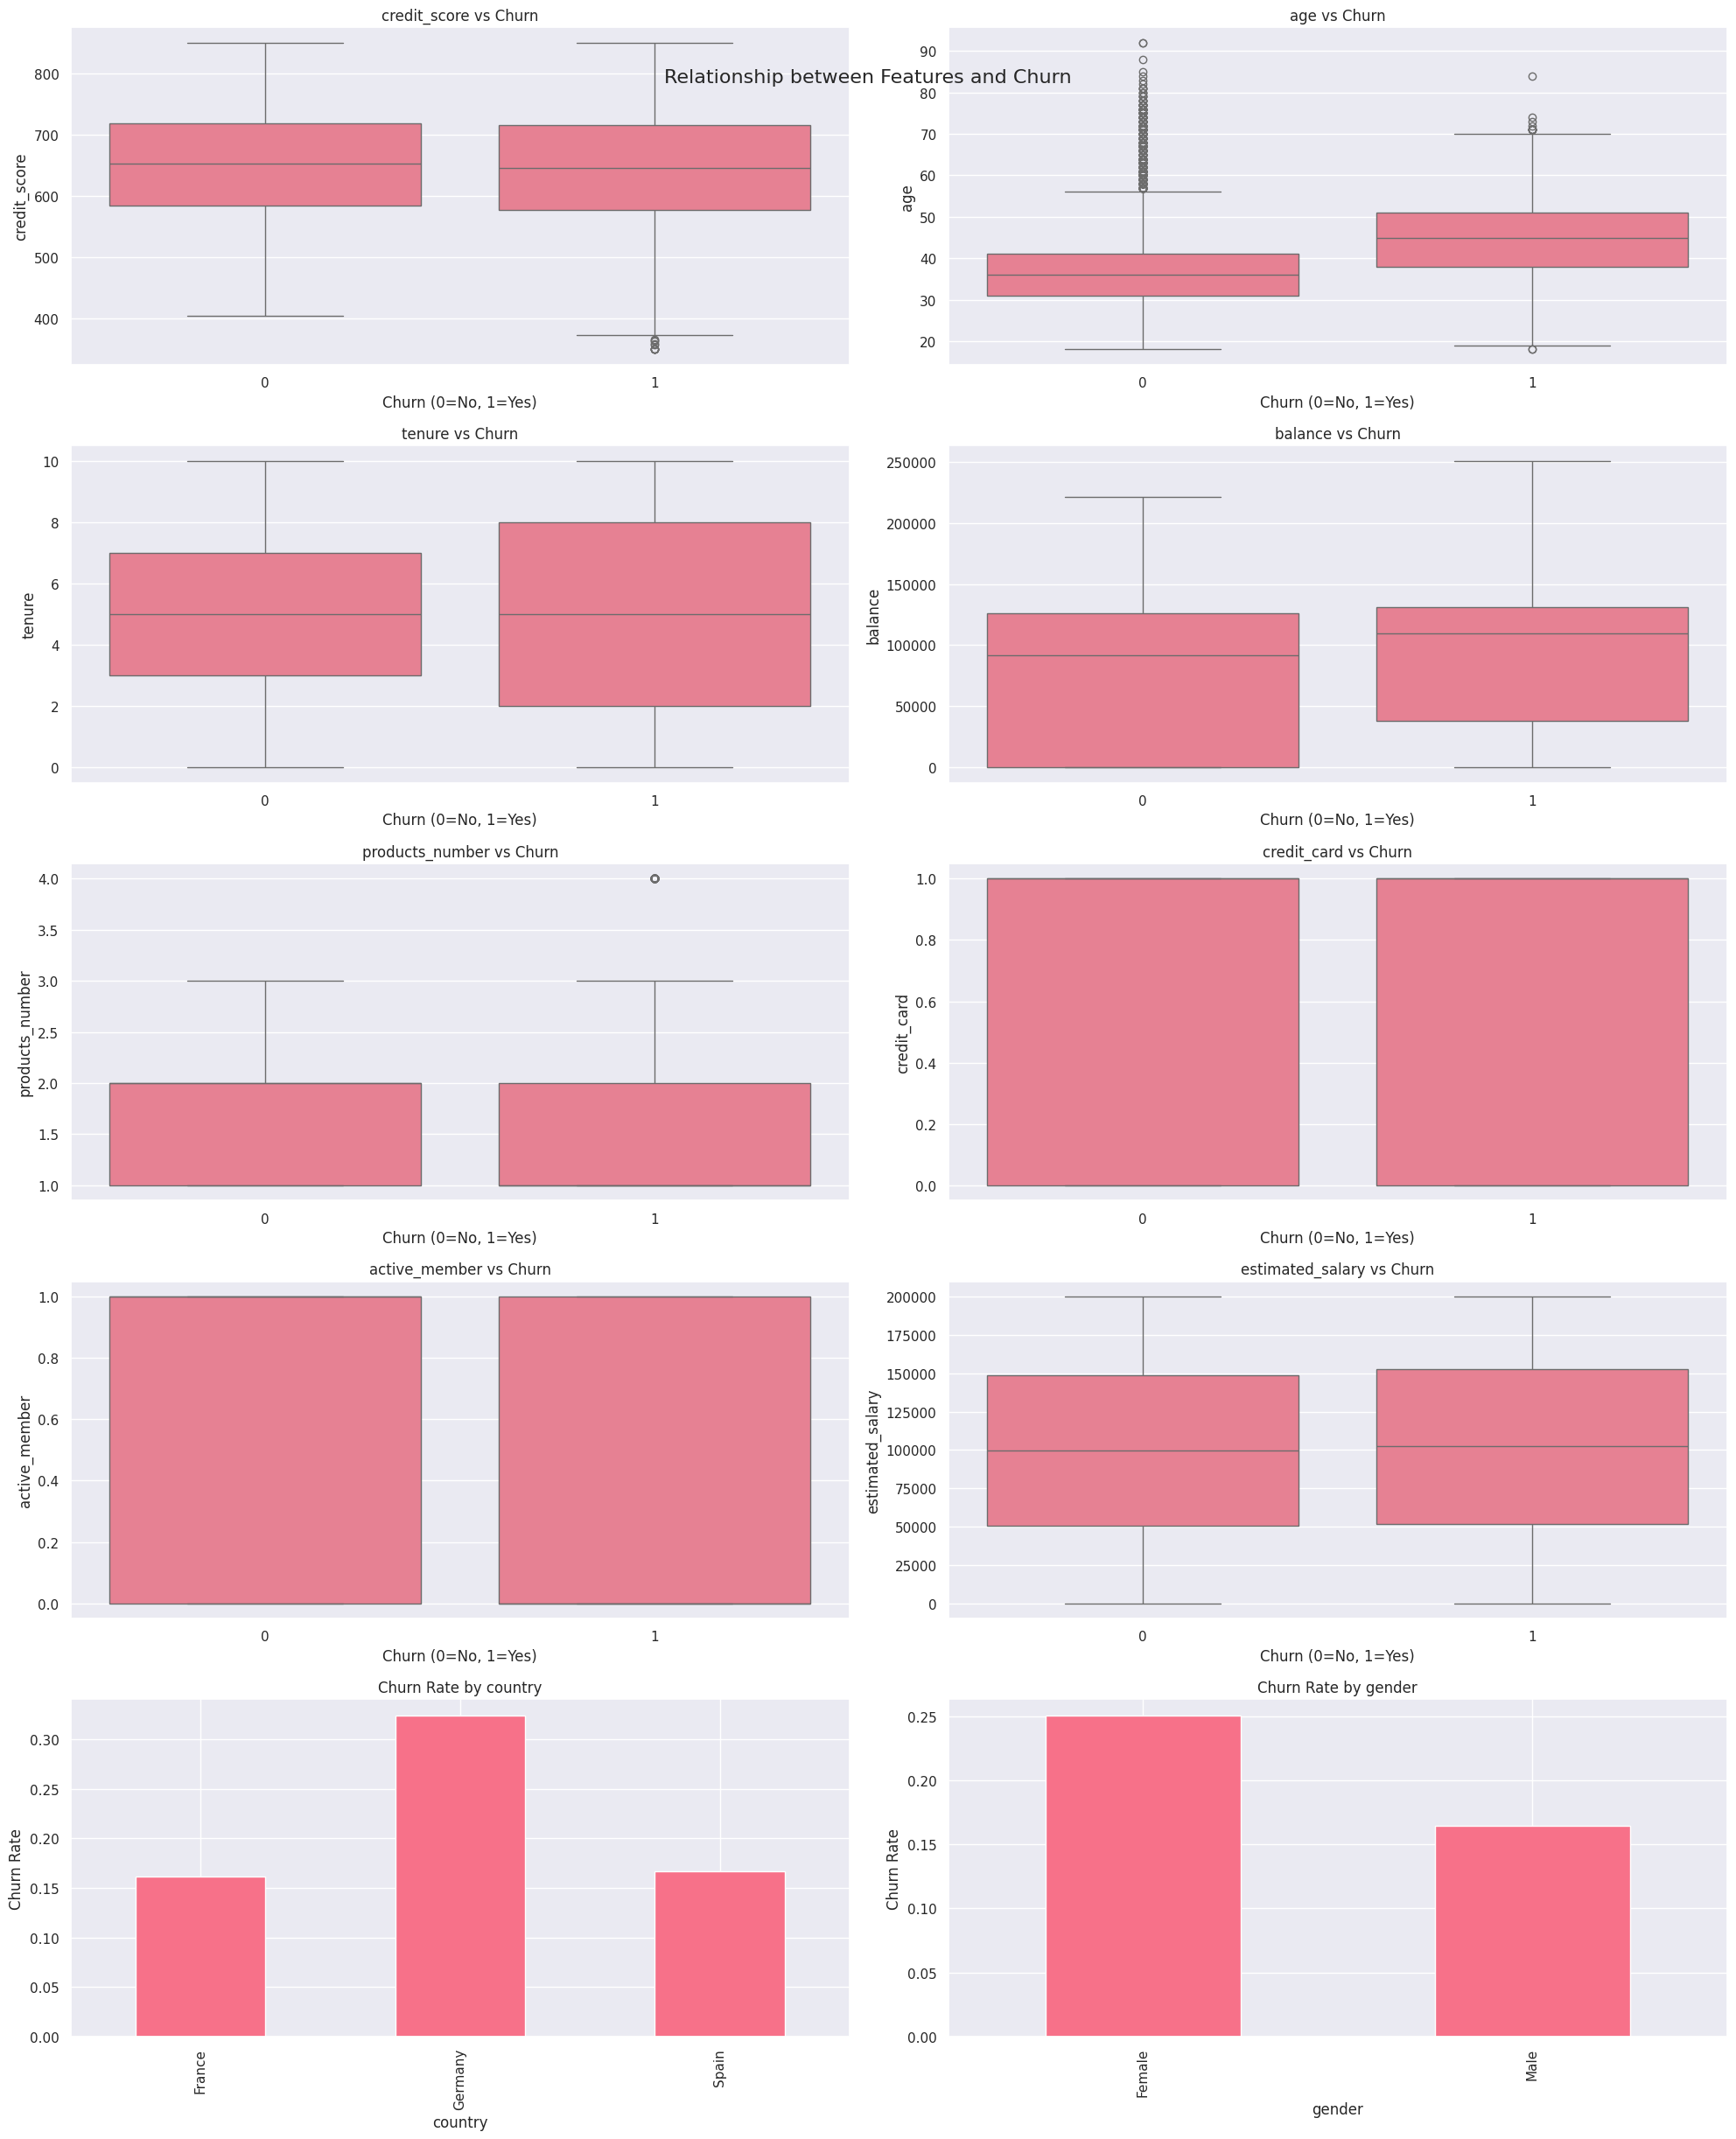

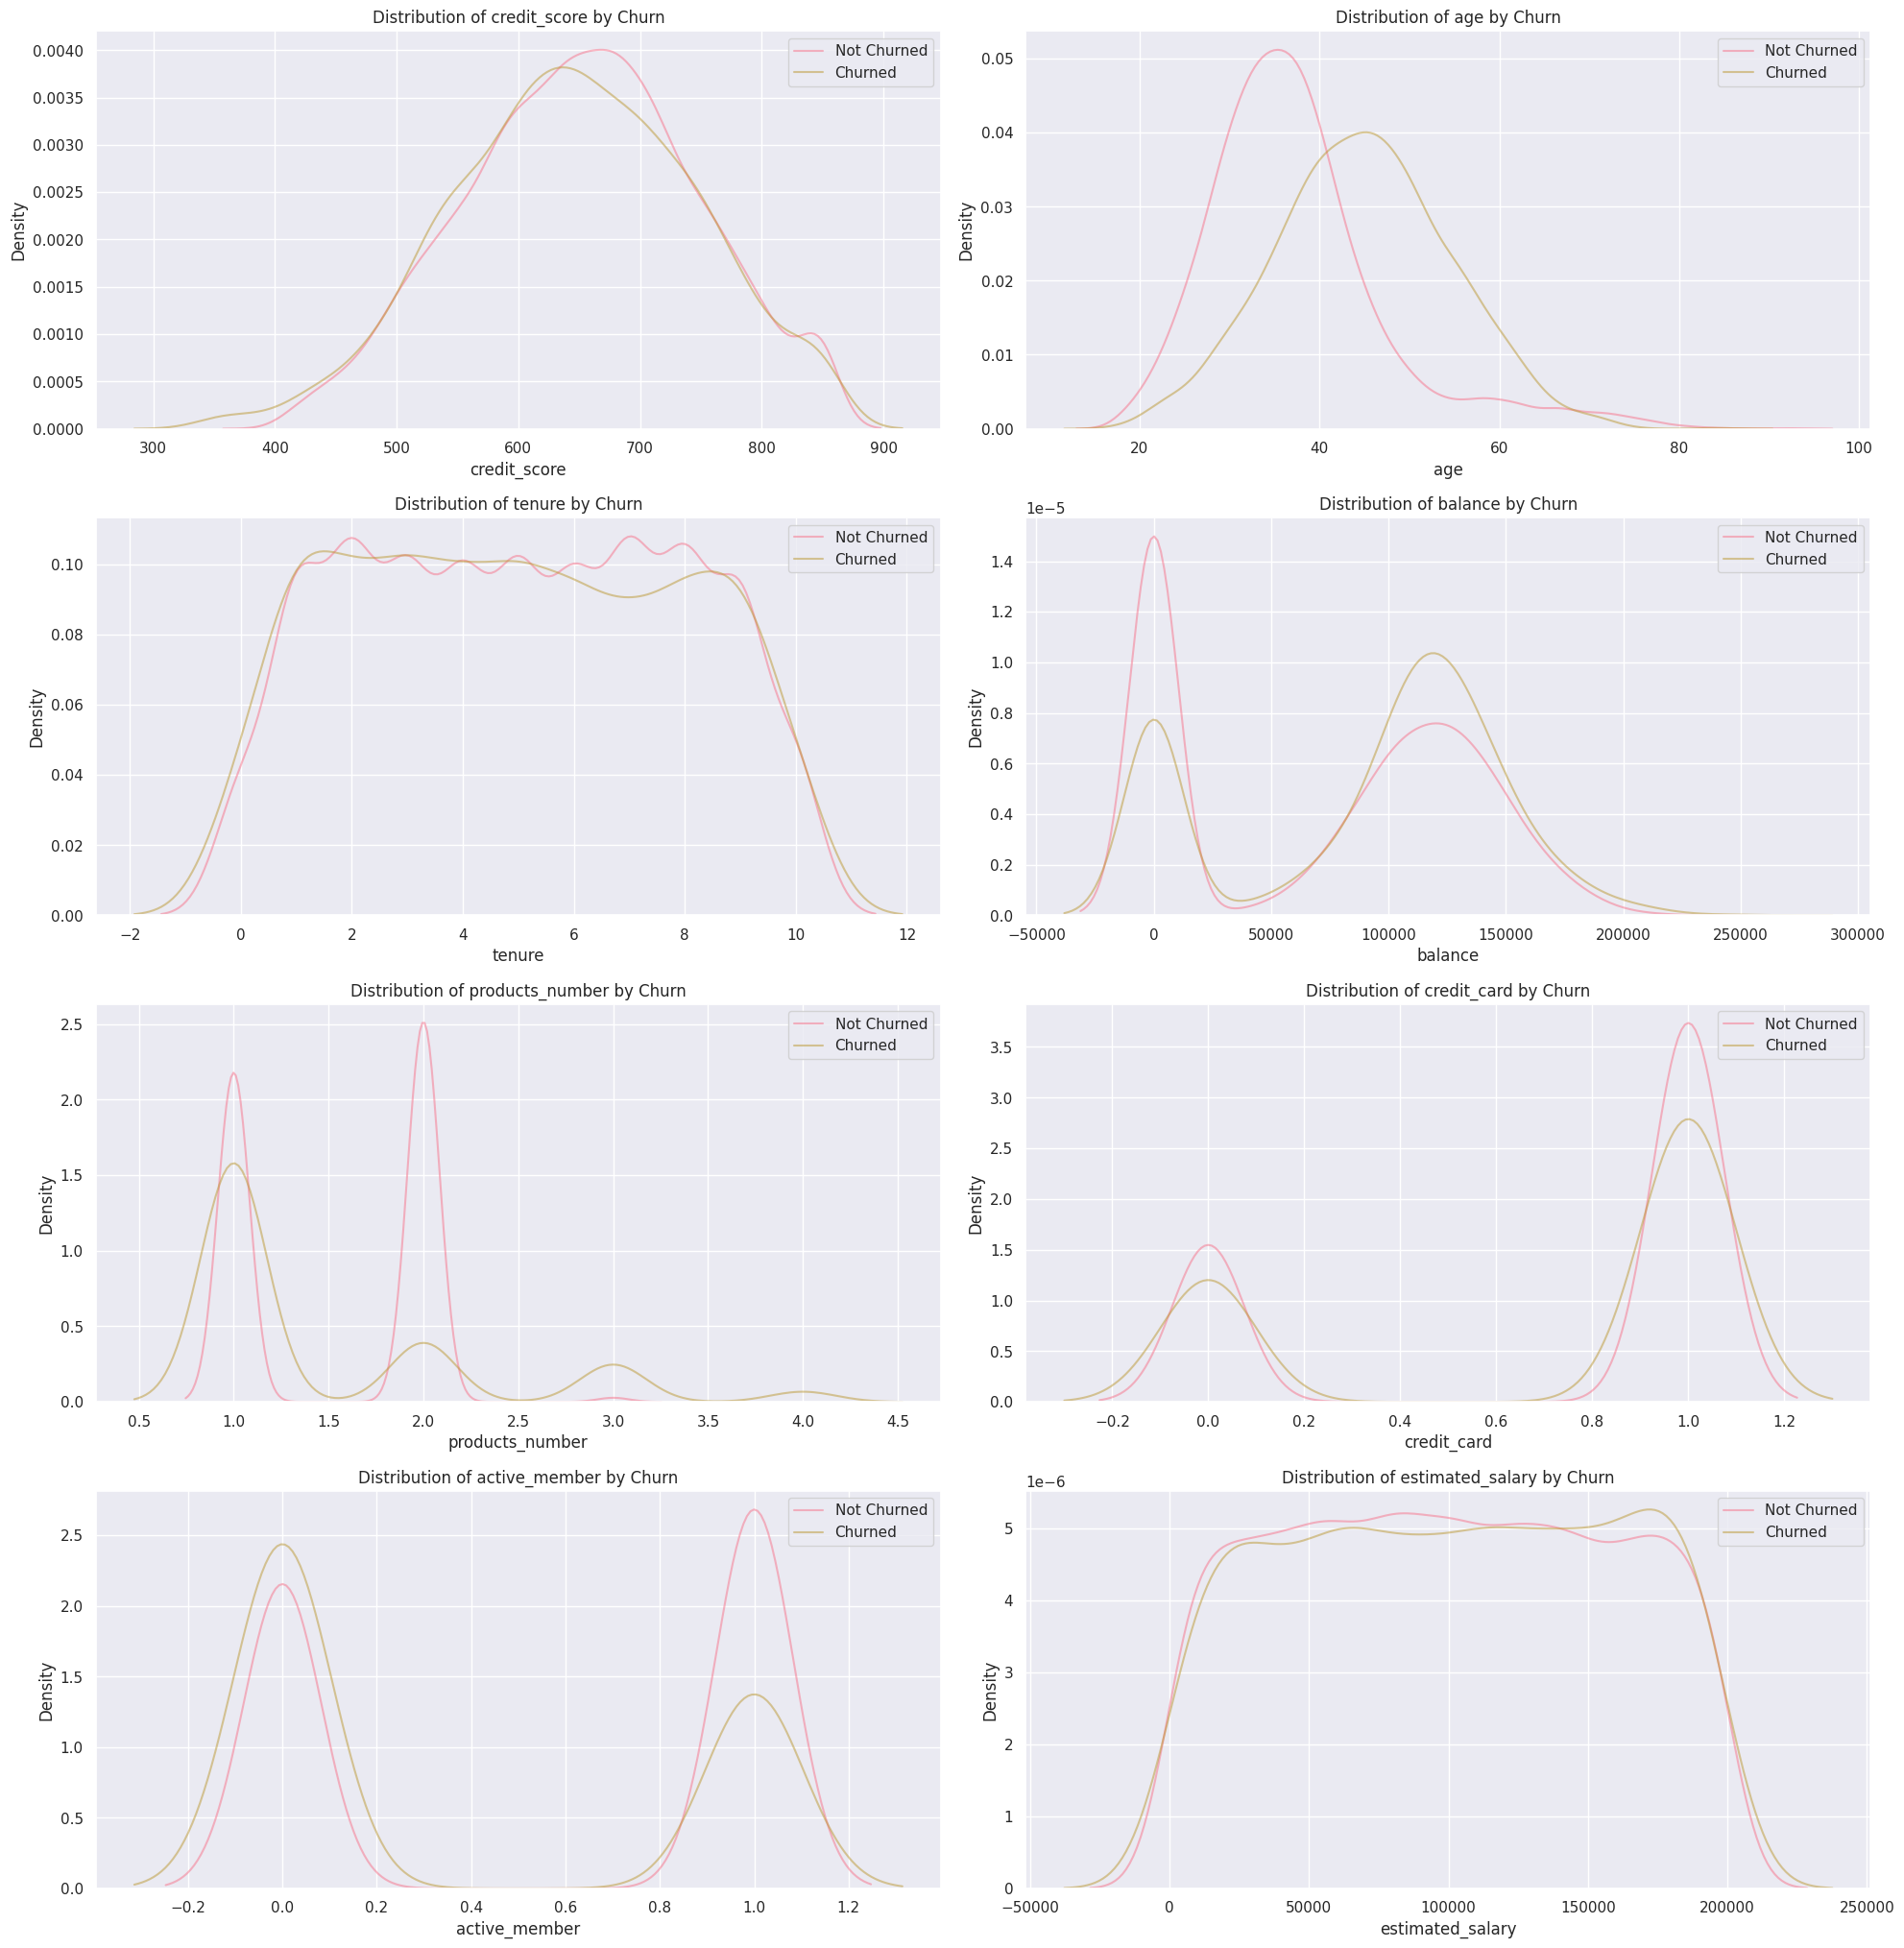

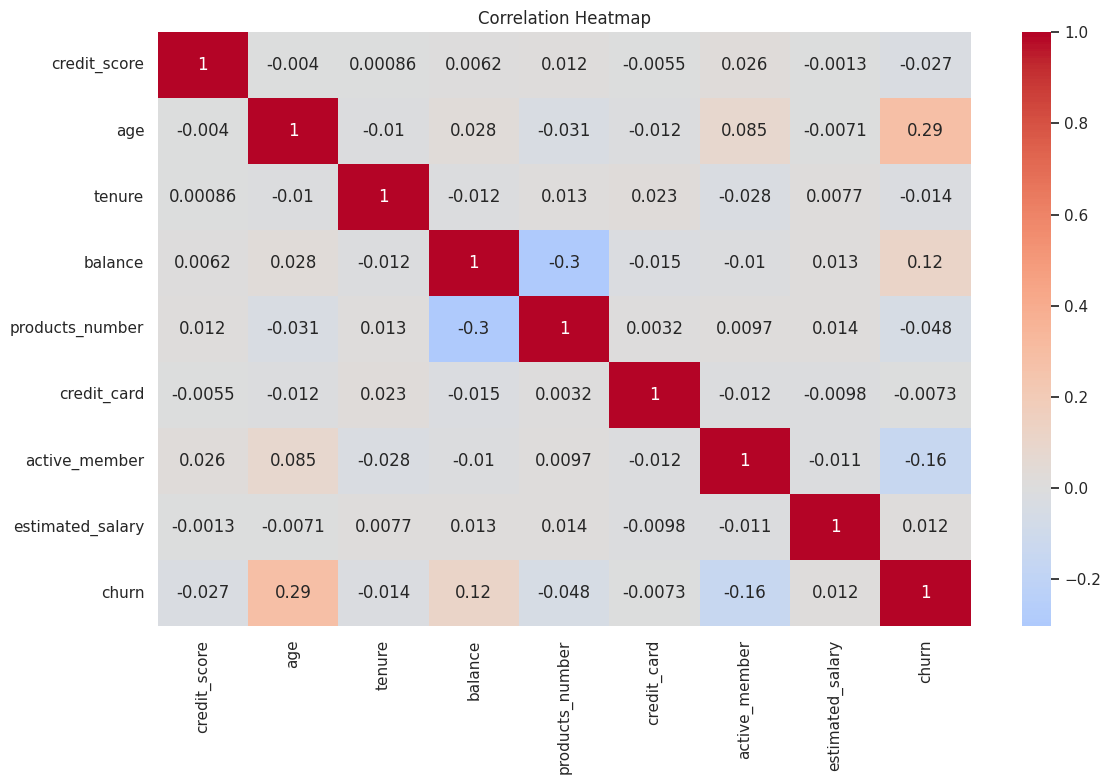

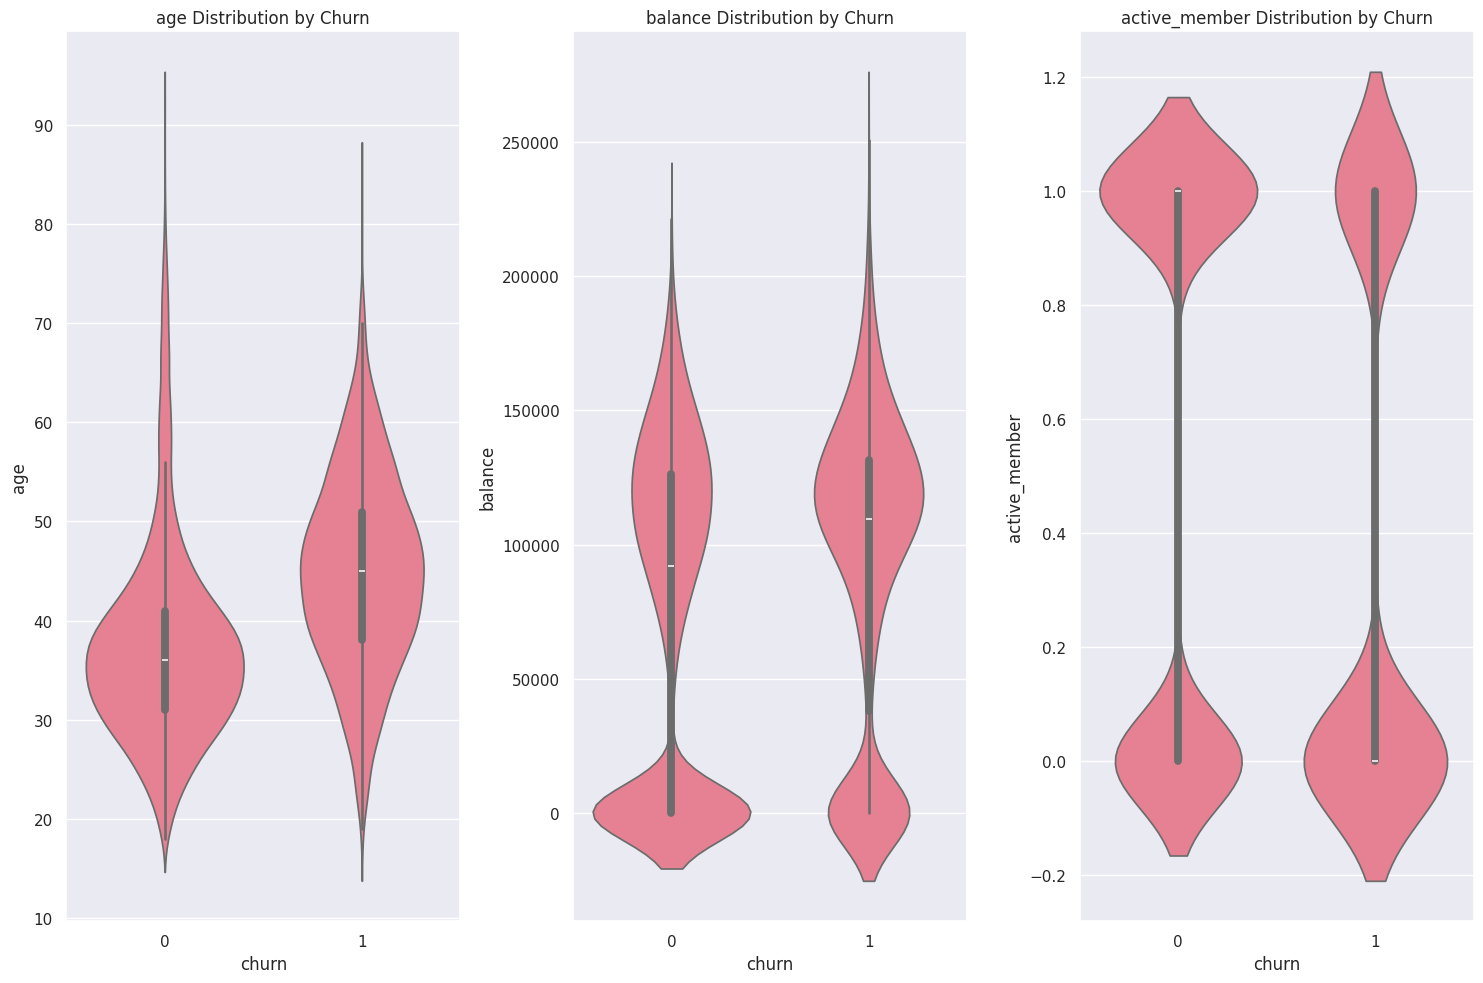

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert PySpark DataFrame to Pandas for visualization
pandas_df = bank_df.toPandas()

# Set up the plotting style
sns.set_theme()
sns.set_palette("husl")

# Create subplots for all features
numeric_features = ["credit_score", "age", "tenure", "balance", "products_number", 
                   "credit_card", "active_member", "estimated_salary"]
categorical_features = ["country", "gender"]

# Calculate number of rows needed for subplots
total_features = len(numeric_features) + len(categorical_features)
n_rows = (total_features + 1) // 2  # 2 columns per row

# Create a figure with subplots
fig = plt.figure(figsize=(20, 5*n_rows))
fig.suptitle('Relationship between Features and Churn', fontsize=16, y=0.95)

# Plot numeric features
for idx, feature in enumerate(numeric_features, 1):
    plt.subplot(n_rows, 2, idx)
    
    # Create box plots for numeric features
    sns.boxplot(x='churn', y=feature, data=pandas_df)
    plt.title(f'{feature} vs Churn')
    plt.xlabel('Churn (0=No, 1=Yes)')
    
# Plot categorical features
for idx, feature in enumerate(categorical_features, len(numeric_features) + 1):
    plt.subplot(n_rows, 2, idx)
    
    # Create bar plots for categorical features
    churn_rates = pandas_df.groupby(feature)['churn'].mean()
    churn_rates.plot(kind='bar')
    plt.title(f'Churn Rate by {feature}')
    plt.ylabel('Churn Rate')
    
plt.tight_layout()
plt.show()

# Create additional distribution plots
plt.figure(figsize=(20, 5*n_rows))
fig.suptitle('Distribution of Features by Churn Status', fontsize=16, y=0.95)

# Plot distributions for numeric features
for idx, feature in enumerate(numeric_features, 1):
    plt.subplot(n_rows, 2, idx)
    
    # Create KDE plots for both churned and non-churned customers
    sns.kdeplot(data=pandas_df[pandas_df['churn']==0][feature], label='Not Churned', alpha=0.5)
    sns.kdeplot(data=pandas_df[pandas_df['churn']==1][feature], label='Churned', alpha=0.5)
    plt.title(f'Distribution of {feature} by Churn')
    plt.legend()

plt.tight_layout()
plt.show()

# Create a correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = pandas_df[numeric_features + ['churn']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Create violin plots for key numeric features
plt.figure(figsize=(15, 10))
key_features = ['age', 'balance', 'active_member']  # Features with stronger correlations
for idx, feature in enumerate(key_features, 1):
    plt.subplot(1, 3, idx)
    sns.violinplot(x='churn', y=feature, data=pandas_df)
    plt.title(f'{feature} Distribution by Churn')

plt.tight_layout()
plt.show()

### 3. Feature Engineering


In [19]:
from pyspark.sql import functions as F

# 1. Age-Related Features
print("Adding age-related features...")
bank_df = bank_df.withColumn(
    'age_group', 
    F.when(F.col('age') < 30, 'Young')
    .when((F.col('age') >= 30) & (F.col('age') < 50), 'Middle-Aged')
    .otherwise('Senior')
)
bank_df = bank_df.withColumn('is_senior', F.when(F.col('age') >= 60, 1).otherwise(0))

# 2. Balance-Related Features
print("Adding balance-related features...")
bank_df = bank_df.withColumn(
    'balance_category',
    F.when(F.col('balance') == 0, 'Zero')
    .when(F.col('balance') < 50000, 'Low')
    .when(F.col('balance') < 100000, 'Medium')
    .otherwise('High')
)
bank_df = bank_df.withColumn(
    'balance_salary_ratio',
    F.col('balance') / F.when(F.col('estimated_salary') == 0, 1).otherwise(F.col('estimated_salary'))
)

# 3. Product-Related Features
print("Adding product-related features...")
bank_df = bank_df.withColumn(
    'product_engagement_score',
    F.col('products_number') * F.col('active_member')
)
bank_df = bank_df.withColumn(
    'is_multi_product',
    F.when(F.col('products_number') > 1, 1).otherwise(0)
)

# 4. Tenure-Related Features
print("Adding tenure-related features...")
bank_df = bank_df.withColumn(
    'tenure_group',
    F.when(F.col('tenure') <= 2, 'New')
    .when((F.col('tenure') > 2) & (F.col('tenure') <= 5), 'Established')
    .otherwise('Loyal')
)
bank_df = bank_df.withColumn(
    'avg_balance_per_tenure',
    F.col('balance') / (F.col('tenure') + 1)
)

# 5. Credit-Related Features
print("Adding credit-related features...")
bank_df = bank_df.withColumn(
    'credit_score_category',
    F.when(F.col('credit_score') < 600, 'Poor')
    .when((F.col('credit_score') >= 600) & (F.col('credit_score') < 700), 'Fair')
    .when((F.col('credit_score') >= 700) & (F.col('credit_score') < 800), 'Good')
    .otherwise('Excellent')
)
bank_df = bank_df.withColumn(
    'credit_balance_ratio',
    F.col('balance') / F.when(F.col('credit_score') == 0, 1).otherwise(F.col('credit_score'))
)

# 6. Customer Value Features
print("Adding customer value features...")
bank_df = bank_df.withColumn(
    'customer_value_score',
    (F.col('balance') * 0.4 + 
     F.col('estimated_salary') * 0.3 +
     F.col('credit_score') * 0.3) / 1000
)

# 7. Risk Score
print("Adding risk indicators...")
bank_df = bank_df.withColumn(
    'risk_score',
    (1000 - F.col('credit_score')) * 0.5 +
    (F.when(F.col('balance') == 0, 100).otherwise(0)) * 0.3 +
    (F.when(F.col('active_member') == 0, 100).otherwise(0)) * 0.2
)

# 8. Activity Level
bank_df = bank_df.withColumn(
    'activity_level',
    F.when(
        (F.col('active_member') == 1) &
        (F.col('products_number') > 1) &
        (F.col('balance') > 0),
        'High'
    ).when(
        (F.col('active_member') == 1) &
        (F.col('products_number') == 1),
        'Medium'
    ).otherwise('Low')
)

# Verify new columns
print("\nNew DataFrame structure:")
bank_df.printSchema()

print("\nSample of new features:")
bank_df.select([
    'age_group', 'balance_category', 'product_engagement_score',
    'tenure_group', 'credit_score_category', 'customer_value_score',
    'risk_score', 'activity_level'
]).show(5)

# Count of total features
print(f"\nTotal number of features: {len(bank_df.columns)}")

Adding age-related features...
Adding balance-related features...
Adding product-related features...
Adding tenure-related features...
Adding credit-related features...
Adding customer value features...
Adding risk indicators...

New DataFrame structure:
root
 |-- credit_score: integer (nullable = true)
 |-- country: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- balance: double (nullable = true)
 |-- products_number: integer (nullable = true)
 |-- credit_card: integer (nullable = true)
 |-- active_member: integer (nullable = true)
 |-- estimated_salary: double (nullable = true)
 |-- churn: integer (nullable = true)
 |-- age_group: string (nullable = false)
 |-- is_senior: integer (nullable = false)
 |-- balance_category: string (nullable = false)
 |-- balance_salary_ratio: double (nullable = true)
 |-- product_engagement_score: integer (nullable = true)
 |-- is_multi_product: integer (nulla

In [20]:
bank_df.show(1)

+------------+-------+------+---+------+-------+---------------+-----------+-------------+----------------+-----+-----------+---------+----------------+--------------------+------------------------+----------------+------------+----------------------+---------------------+--------------------+--------------------+----------+--------------+
|credit_score|country|gender|age|tenure|balance|products_number|credit_card|active_member|estimated_salary|churn|  age_group|is_senior|balance_category|balance_salary_ratio|product_engagement_score|is_multi_product|tenure_group|avg_balance_per_tenure|credit_score_category|credit_balance_ratio|customer_value_score|risk_score|activity_level|
+------------+-------+------+---+------+-------+---------------+-----------+-------------+----------------+-----+-----------+---------+----------------+--------------------+------------------------+----------------+------------+----------------------+---------------------+--------------------+--------------------+-

### 4. Data Preprocessing for ML Model

In [21]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.functions import vector_to_array
from pyspark.sql.types import DoubleType

# 1. Identify categorical and numerical columns
categorical_cols = [
    'country', 'gender', 'age_group', 'balance_category', 
    'tenure_group', 'credit_score_category', 'activity_level'
]

numerical_cols = [
    'credit_score', 'age', 'tenure', 'balance', 'products_number',
    'credit_card', 'active_member', 'estimated_salary', 'is_senior',
    'balance_salary_ratio', 'product_engagement_score', 'is_multi_product',
    'avg_balance_per_tenure', 'credit_balance_ratio', 'customer_value_score',
    'risk_score'
]

# 2. Create stages for the pipeline
stages = []

# Handle categorical features
# First convert string columns to indices
indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_index", handleInvalid="keep")
    for col in categorical_cols
]
stages.extend(indexers)

# Convert indices to one-hot encodings
encoders = [
    OneHotEncoder(
        inputCols=[f"{col}_index" for col in categorical_cols],
        outputCols=[f"{col}_vec" for col in categorical_cols]
    )
]
stages.extend(encoders)

# 3. Assemble all features into a single vector
# Combine all one-hot encoded and numerical columns
assembler_inputs = [f"{col}_vec" for col in categorical_cols] + numerical_cols
assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features_unscaled",
    handleInvalid="keep"
)
stages.append(assembler)

# 4. Scale the features
scaler = StandardScaler(
    inputCol="features_unscaled",
    outputCol="features",
    withStd=True,
    withMean=True
)
stages.append(scaler)

# 5. Create and apply the pipeline
print("Creating and applying preprocessing pipeline...")
pipeline = Pipeline(stages=stages)
model = pipeline.fit(bank_df)
processed_df = model.transform(bank_df)

# 6. Select only the features and label columns
final_df = processed_df.select("features", F.col("churn").cast("double").alias("label"))

# 7. Split the data
print("Splitting into train and test sets...")
train_df, test_df = final_df.randomSplit([0.8, 0.2], seed=42)

# Print some information about the splits
print(f"\nTraining set size: {train_df.count()}")
print(f"Test set size: {test_df.count()}")



# 8. Verify the preprocessing
print("\nProcessed feature vector sample:")
processed_df.select("features").show(2, truncate=False)


print("\nPreprocessing complete!")

Creating and applying preprocessing pipeline...
Splitting into train and test sets...

Training set size: 8078
Test set size: 1921

Processed feature vector sample:
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                                      

### 5. Model Training and Evaluation

In [22]:
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier,
    GBTClassifier,
    DecisionTreeClassifier
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Function to evaluate model performance
def evaluate_model(predictions, model_name):
    # Binary Classification Evaluator for AUC
    evaluator_auc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )
    
    # MultiClass Evaluator for Accuracy, Precision, Recall
    evaluator_multi = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction"
    )
    
    accuracy = evaluator_multi.setMetricName("accuracy").evaluate(predictions)
    precision = evaluator_multi.setMetricName("weightedPrecision").evaluate(predictions)
    recall = evaluator_multi.setMetricName("weightedRecall").evaluate(predictions)
    f1 = evaluator_multi.setMetricName("f1").evaluate(predictions)
    auc = evaluator_auc.evaluate(predictions)
    
    print(f"\n{model_name} Performance Metrics:")
    print("-" * 50)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {auc:.4f}")
    
    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }

# List to store all model results
model_results = []

# 1. Logistic Regression
print("\nTraining Logistic Regression...")
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=10,
    regParam=0.1,
    elasticNetParam=0.8
)
lr_model = lr.fit(train_df)
lr_predictions = lr_model.transform(test_df)
model_results.append(evaluate_model(lr_predictions, "Logistic Regression"))

# 2. Random Forest
print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=5,
    seed=42
)
rf_model = rf.fit(train_df)
rf_predictions = rf_model.transform(test_df)
model_results.append(evaluate_model(rf_predictions, "Random Forest"))





Training Logistic Regression...

Logistic Regression Performance Metrics:
--------------------------------------------------
Accuracy: 0.8017
Precision: 0.6427
Recall: 0.8017
F1 Score: 0.7134
AUC-ROC: 0.7364

Training Random Forest...

Random Forest Performance Metrics:
--------------------------------------------------
Accuracy: 0.8615
Precision: 0.8670
Recall: 0.8615
F1 Score: 0.8351
AUC-ROC: 0.8553


In [23]:

# 3. Gradient Boosted Trees
print("\nTraining Gradient Boosted Trees...")
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    maxIter=10,
    maxDepth=5,
    seed=42
)
gbt_model = gbt.fit(train_df)
gbt_predictions = gbt_model.transform(test_df)
model_results.append(evaluate_model(gbt_predictions, "Gradient Boosted Trees"))

# 4. Decision Tree
print("\nTraining Decision Tree...")
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    maxDepth=5,
    seed=42
)
dt_model = dt.fit(train_df)
dt_predictions = dt_model.transform(test_df)
model_results.append(evaluate_model(dt_predictions, "Decision Tree"))




Training Gradient Boosted Trees...

Gradient Boosted Trees Performance Metrics:
--------------------------------------------------
Accuracy: 0.8699
Precision: 0.8642
Recall: 0.8699
F1 Score: 0.8543
AUC-ROC: 0.8569

Training Decision Tree...

Decision Tree Performance Metrics:
--------------------------------------------------
Accuracy: 0.8605
Precision: 0.8503
Recall: 0.8605
F1 Score: 0.8461
AUC-ROC: 0.2565


In [24]:
# Compare all models
print("\nModel Comparison Summary:")
print("-" * 80)
print(f"{'Model':<25} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1':<10} {'AUC':<10}")
print("-" * 80)
for result in model_results:
    print(f"{result['model']:<25} {result['accuracy']:<10.4f} {result['precision']:<10.4f} "
          f"{result['recall']:<10.4f} {result['f1']:<10.4f} {result['auc']:<10.4f}")

# Find best model based on F1 score
best_model = max(model_results, key=lambda x: x['f1'])
print(f"\nBest performing model based on F1 score: {best_model['model']}")
print(f"F1 Score: {best_model['f1']:.4f}")



Model Comparison Summary:
--------------------------------------------------------------------------------
Model                     Accuracy   Precision  Recall     F1         AUC       
--------------------------------------------------------------------------------
Logistic Regression       0.8017     0.6427     0.8017     0.7134     0.7364    
Random Forest             0.8615     0.8670     0.8615     0.8351     0.8553    
Gradient Boosted Trees    0.8699     0.8642     0.8699     0.8543     0.8569    
Decision Tree             0.8605     0.8503     0.8605     0.8461     0.2565    

Best performing model based on F1 score: Gradient Boosted Trees
F1 Score: 0.8543


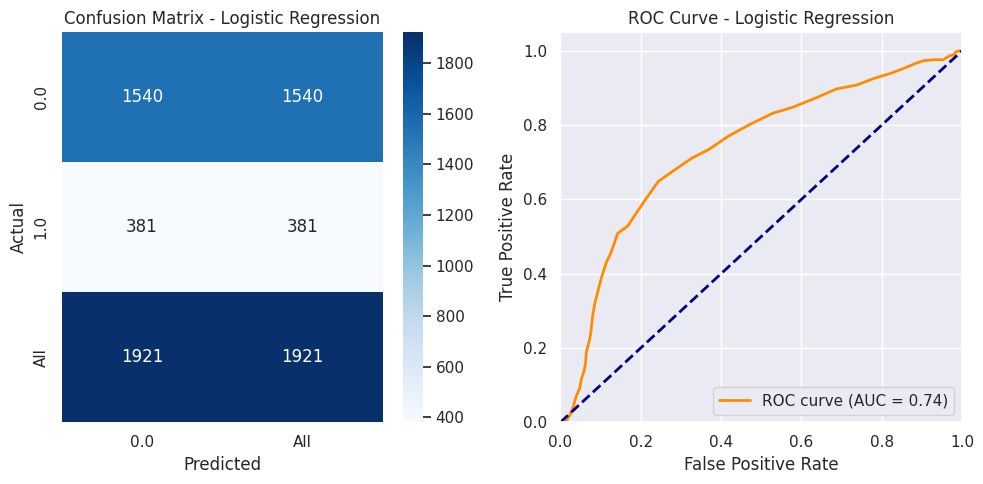


Detailed Metrics for Logistic Regression:
--------------------------------------------------

Confusion Matrix:
prediction   0.0   All
label                 
0.0         1540  1540
1.0          381   381
All         1921  1921

Specificity (True Negative Rate): 0.5000
Sensitivity (True Positive Rate): 0.5000


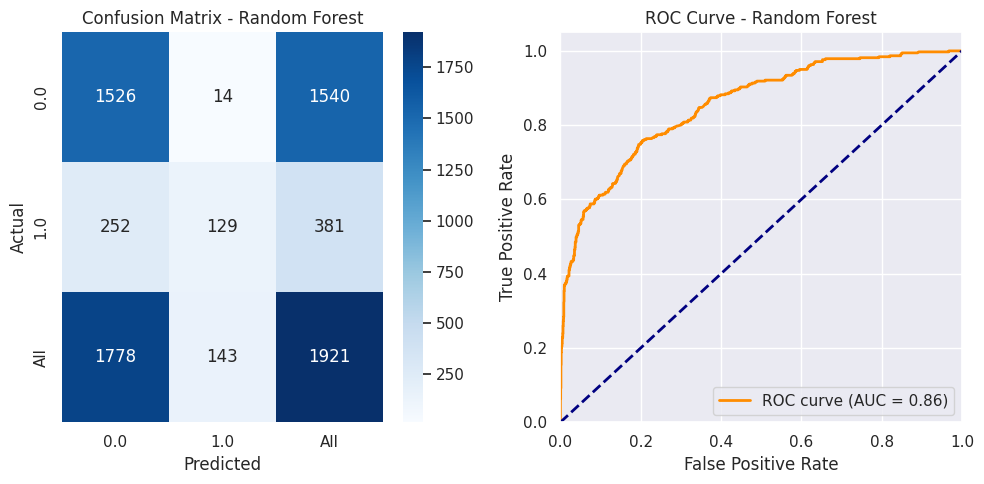


Detailed Metrics for Random Forest:
--------------------------------------------------

Confusion Matrix:
prediction   0.0  1.0   All
label                      
0.0         1526   14  1540
1.0          252  129   381
All         1778  143  1921

Specificity (True Negative Rate): 0.9909
Sensitivity (True Positive Rate): 0.3386


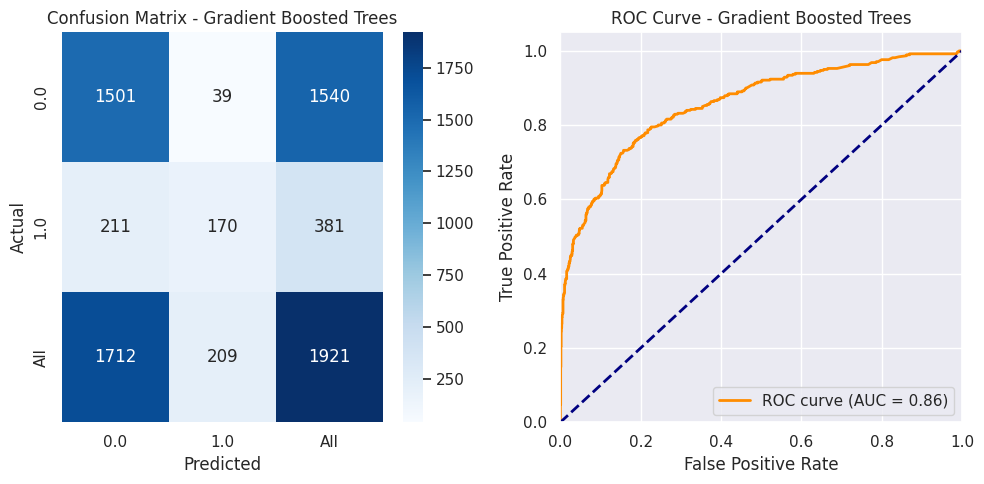


Detailed Metrics for Gradient Boosted Trees:
--------------------------------------------------

Confusion Matrix:
prediction   0.0  1.0   All
label                      
0.0         1501   39  1540
1.0          211  170   381
All         1712  209  1921

Specificity (True Negative Rate): 0.9747
Sensitivity (True Positive Rate): 0.4462


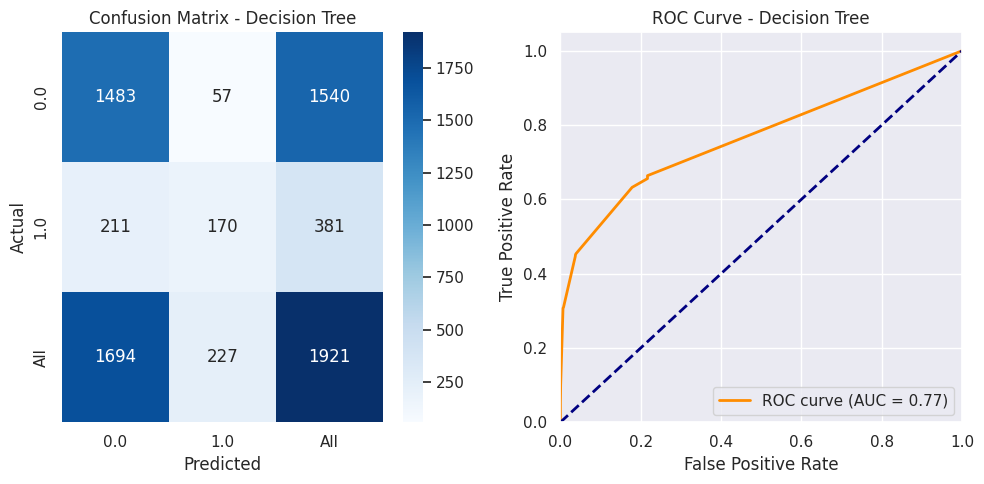


Detailed Metrics for Decision Tree:
--------------------------------------------------

Confusion Matrix:
prediction   0.0  1.0   All
label                      
0.0         1483   57  1540
1.0          211  170   381
All         1694  227  1921

Specificity (True Negative Rate): 0.9630
Sensitivity (True Positive Rate): 0.4462


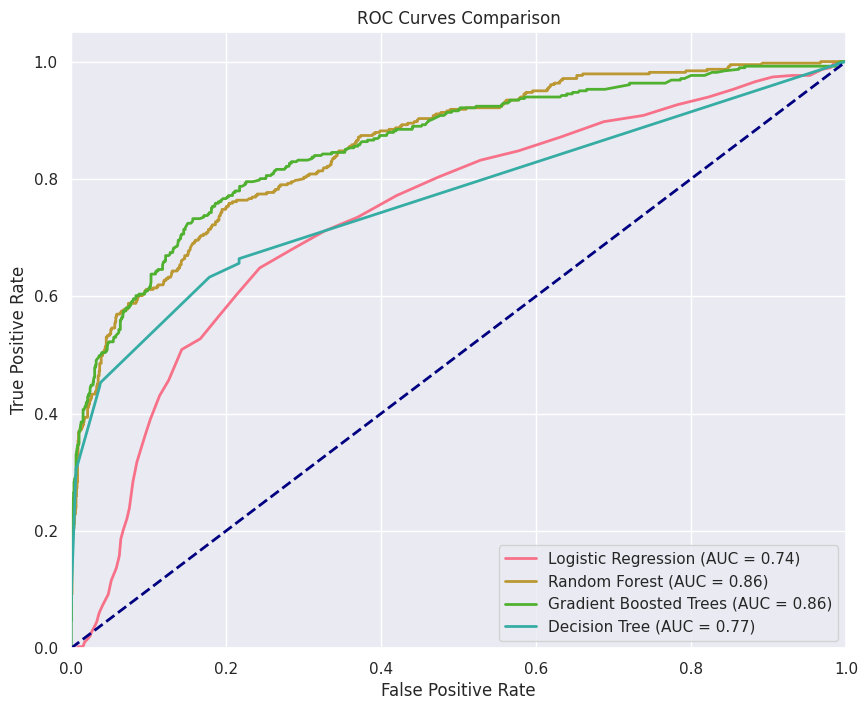

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_curve, auc, confusion_matrix
from pyspark.sql.functions import col, when

from pyspark.sql.functions import col, when

def plot_confusion_matrix_and_roc(predictions, model_name):
    # Convert predictions to pandas for easier plotting
    pred_pd = predictions.select("label", "prediction", "probability").toPandas()
    
    # Confusion Matrix
    plt.figure(figsize=(10, 5))
    
    # Plot 1: Confusion Matrix
    plt.subplot(1, 2, 1)
    cm = pd.crosstab(pred_pd['label'], pred_pd['prediction'], margins=True)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    # Plot 2: ROC Curve
    plt.subplot(1, 2, 2)
    # Extract probabilities for class 1
    pred_pd['probability_1'] = pred_pd['probability'].apply(lambda x: x[1])
    
    # Calculate FPR, TPR for ROC curve
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(pred_pd['label'], pred_pd['probability_1'])
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed classification metrics
    print(f"\nDetailed Metrics for {model_name}:")
    print("-" * 50)
    print("\nConfusion Matrix:")
    print(cm)
    
    # Calculate additional metrics
    tn = cm.iloc[0,0]
    fp = cm.iloc[0,1]
    fn = cm.iloc[1,0]
    tp = cm.iloc[1,1]
    
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)
    
    print(f"\nSpecificity (True Negative Rate): {specificity:.4f}")
    print(f"Sensitivity (True Positive Rate): {sensitivity:.4f}")

# Modify your existing code to include these visualizations
# After each model's evaluation, add:

# For Logistic Regression
plot_confusion_matrix_and_roc(lr_predictions, "Logistic Regression")

# For Random Forest
plot_confusion_matrix_and_roc(rf_predictions, "Random Forest")

# For Gradient Boosted Trees
plot_confusion_matrix_and_roc(gbt_predictions, "Gradient Boosted Trees")

# For Decision Tree
plot_confusion_matrix_and_roc(dt_predictions, "Decision Tree")

# Optional: Plot all ROC curves in one figure for comparison
plt.figure(figsize=(10, 8))
models = {
    "Logistic Regression": lr_predictions,
    "Random Forest": rf_predictions,
    "Gradient Boosted Trees": gbt_predictions,
    "Decision Tree": dt_predictions
}

for model_name, predictions in models.items():
    pred_pd = predictions.select("label", "probability").toPandas()
    pred_pd['probability_1'] = pred_pd['probability'].apply(lambda x: x[1])
    fpr, tpr, _ = roc_curve(pred_pd['label'], pred_pd['probability_1'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.show()


